# Question (2a)

In [ ]:
# ============================================================
#  Setup + config (REPLACE)
# ============================================================

import os
import re
import json
import math
import random
import inspect
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# paths
# Resolve paths against the repository root, so this notebook works whether
# it is launched from notebooks/ or from the repository root.
ROOT = ".." if os.path.basename(os.getcwd()) == "notebooks" else "."
TRAIN_PATH = os.path.join(ROOT, "data", "processed", "train.csv")
DEV_PATH   = os.path.join(ROOT, "data", "processed", "dev.csv")
TEST_PATH  = os.path.join(ROOT, "data", "processed", "test.csv")


LABEL_COL = "label"
SRC_COL   = "source_text"
RPL_COL   = "reply_text"
ID_COL: Optional[str] = None


MODEL_NAME = "vinai/bertweet-base"
MAX_LEN    = 256
SEED = 42
PATIENCE = 2

LR           = 1.5e-5
WEIGHT_DECAY = 0.05
WARMUP_RATIO = 0.10


EPOCHS_4WAY   = 8
EPOCHS_STAGE1 = 6
EPOCHS_STAGE2 = 6

BS_TRAIN = 8
BS_EVAL  = 32
GRAD_ACCUM = 2


LABEL_SMOOTHING = 0.10
MAX_GRAD_NORM   = 1.0


DROPOUT = 0.20

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

# Device
if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

USE_FP16 = (DEVICE == "cuda")
set_seed(SEED)

print("Device:", DEVICE, "| fp16:", USE_FP16)


Device: mps | fp16: False


In [ ]:
# ============================================================
# Load data
# ============================================================

def _auto_detect_id_col(df: pd.DataFrame) -> Optional[str]:
    candidates = ["tweet_id", "id", "tweetId", "tweetid", "reply_id"]
    for c in candidates:
        if c in df.columns:
            return c
    return None

def load_df(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    for col in [LABEL_COL, SRC_COL, RPL_COL]:
        if col not in df.columns:
            raise ValueError(f"Missing column '{col}' in {path}. Found columns: {list(df.columns)}")

    df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()
    df[SRC_COL]   = df[SRC_COL].astype(str).fillna("")
    df[RPL_COL]   = df[RPL_COL].astype(str).fillna("")

    global ID_COL
    if ID_COL is None:
        ID_COL = _auto_detect_id_col(df)

    if ID_COL is None:
        df["__row_id__"] = [str(i) for i in range(len(df))]
        ID_COL = "__row_id__"

    df[ID_COL] = df[ID_COL].astype(str)
    return df

train_df = load_df(TRAIN_PATH)
dev_df   = load_df(DEV_PATH)
test_df  = load_df(TEST_PATH)

print("Train:", train_df.shape, "Dev:", dev_df.shape, "Test:", test_df.shape)
print("Label distribution (train):")
print(train_df[LABEL_COL].value_counts())
print("Using ID_COL =", ID_COL)


Train: (3569, 22) Dev: (950, 22) Test: (1049, 4)
Label distribution (train):
label
C    2291
S     743
D     273
Q     262
Name: count, dtype: int64
Using ID_COL = tweet_id


In [ ]:
# ============================================================
# Normalization
# ============================================================

URL_RE = re.compile(r"http\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")

def normalize_tweet(text: str) -> str:
    text = text.strip()
    text = URL_RE.sub("HTTPURL", text)
    text = MENTION_RE.sub("@USER", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in [train_df, dev_df, test_df]:
    df["source_norm"] = df[SRC_COL].map(normalize_tweet)
    df["reply_norm"]  = df[RPL_COL].map(normalize_tweet)

print(train_df[["source_norm","reply_norm",LABEL_COL]].head(3))


                                         source_norm  \
0  Question for #Ferguson police chief? If OFFICE...   
1  #Ottawa police confirm to #CBCNews they are st...   
2  URGENT: 3 gunmen involved in deadly attack on ...   

                                          reply_norm label  
0  @USER @USER @USER This shows Michael paid for ...     C  
1  @USER @USER @USER @USER your radical Muslims a...     C  
2                              @USER Just kill them.     C  


In [ ]:
from transformers import AutoTokenizer, DataCollatorWithPadding
from datasets import Dataset
from typing import Dict, Optional

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

_base_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if DEVICE == "cuda" else None
)

class SafeDataCollator:
    """Drops non-tensor fields (e.g., tweet_id strings) before padding/tensor conversion."""
    def __init__(self, base_collator, drop_keys=("tweet_id",)):
        self.base_collator = base_collator
        self.drop_keys = set(drop_keys)

    def __call__(self, features):
        cleaned = []
        for f in features:
            f2 = dict(f)
            for k in list(f2.keys()):
                if k in self.drop_keys:
                    f2.pop(k, None)
            cleaned.append(f2)
        return self.base_collator(cleaned)

data_collator = SafeDataCollator(_base_collator, drop_keys=("tweet_id",))

def build_hf_dataset(
    df: pd.DataFrame,
    label2id: Dict[str, int],
    require_labels: bool = True,
    label_col: Optional[str] = None,
    id_col: Optional[str] = None,
) -> Dataset:
    if label_col is None:
        if not isinstance(LABEL_COL, str):
            raise ValueError("LABEL_COL must be a string column name, e.g. 'label'")
        label_col = LABEL_COL

    if id_col is None:
        if ID_COL is None or not isinstance(ID_COL, str):
            raise ValueError("ID_COL must be set to your tweet id column name (string).")
        id_col = ID_COL

    d = df.copy()

    if "source_norm" not in d.columns or "reply_norm" not in d.columns:
        raise ValueError("Expected columns: source_norm, reply_norm. Run your normalization cell first.")

    d["tweet_id"] = d[id_col].astype(str)
    d["source_norm"] = d["source_norm"].astype(str)
    d["reply_norm"]  = d["reply_norm"].astype(str)

    keep_cols = ["tweet_id", "source_norm", "reply_norm"]

    if require_labels:
        if label_col not in d.columns:
            raise ValueError(f"Missing label column '{label_col}'. Have: {list(d.columns)}")
        d[label_col] = d[label_col].astype(str)
        d["labels"] = d[label_col].map(label2id)

        if d["labels"].isna().any():
            bad = d.loc[d["labels"].isna(), label_col].unique()
            raise ValueError(f"Unmapped labels in '{label_col}': {bad} (expected {list(label2id.keys())})")

        d["labels"] = d["labels"].astype(int)
        keep_cols.append("labels")

    ds = Dataset.from_pandas(d[keep_cols], preserve_index=False)

    def tok(batch):
        return tokenizer(
            batch["source_norm"],
            batch["reply_norm"],
            truncation="only_first",
            max_length=MAX_LEN,
            padding=False,
        )

    ds = ds.map(tok, batched=True, remove_columns=["source_norm", "reply_norm"])
    return ds


In [ ]:
def compute_metrics_factory(id2label: Dict[int,str]):
    labels_sorted = [id2label[i] for i in range(len(id2label))]

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)

        acc = accuracy_score(labels, preds)
        macro = f1_score(labels, preds, average="macro")

        per_class = f1_score(labels, preds, average=None, labels=list(range(len(id2label))))
        per_class_dict = {f"f1_{id2label[i]}": float(per_class[i]) for i in range(len(id2label))}

        return {"accuracy": float(acc), "macro_f1": float(macro), **per_class_dict}

    return compute_metrics

def pretty_confusion(y_true: np.ndarray, y_pred: np.ndarray, id2label: Dict[int,str]) -> pd.DataFrame:
    labels = [id2label[i] for i in range(len(id2label))]
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(id2label))))
    return pd.DataFrame(cm, index=[f"true_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])

def print_report(y_true: np.ndarray, y_pred: np.ndarray, id2label: Dict[int,str]):
    labels = [id2label[i] for i in range(len(id2label))]
    print(classification_report(
        y_true, y_pred,
        target_names=labels,
        digits=4
    ))


In [ ]:
# ============================================================
# Weighted CE Trainer, Label smoothing, LLRD 
# ============================================================

import numpy as np
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import Trainer, TrainingArguments

def make_class_weights_sqrt_inv(y, num_labels: int) -> torch.Tensor:
    counts = np.bincount(np.array(y), minlength=num_labels).astype(np.float64)
    weights = np.sqrt(counts.sum() / (num_labels * np.maximum(counts, 1.0)))
    return torch.tensor(weights, dtype=torch.float32)

def make_training_args(output_dir: str, num_epochs: int) -> TrainingArguments:
    return TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=50,

        learning_rate=LR,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,

        per_device_train_batch_size=BS_TRAIN,
        per_device_eval_batch_size=BS_EVAL,
        gradient_accumulation_steps=GRAD_ACCUM,
        num_train_epochs=num_epochs,

        max_grad_norm=MAX_GRAD_NORM,
        dataloader_pin_memory=False,

        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,

        save_total_limit=2,
        report_to="none",
        fp16=USE_FP16,
        seed=SEED,
    )

class WeightedCE_LLRD_Trainer(Trainer):
    def __init__(self, class_weights: torch.Tensor, base_lr: float, layer_decay: float = 0.9, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.base_lr = float(base_lr)
        self.layer_decay = float(layer_decay)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
        logits = outputs.logits

        cw = self.class_weights.to(device=logits.device, dtype=logits.dtype)

        loss = F.cross_entropy(
            logits,
            labels,
            weight=cw,
            label_smoothing=float(LABEL_SMOOTHING)
        )
        return (loss, outputs) if return_outputs else loss

    def create_optimizer(self):
        if self.optimizer is not None:
            return self.optimizer

        model = self.model

        if hasattr(model, "roberta"):
            base = model.roberta
        else:
            base = getattr(model, model.base_model_prefix)

        layers = list(base.encoder.layer)
        n_layers = len(layers)

        no_decay = ["bias", "LayerNorm.weight", "layer_norm.weight"]

        def is_no_decay(n: str) -> bool:
            return any(nd in n for nd in no_decay)

        param_groups = []

        emb_lr = self.base_lr * (self.layer_decay ** (n_layers + 1))
        emb_params_decay = []
        emb_params_nodecay = []
        for n, p in base.embeddings.named_parameters():
            if not p.requires_grad:
                continue
            (emb_params_nodecay if is_no_decay(n) else emb_params_decay).append(p)
        if emb_params_decay:
            param_groups.append({"params": emb_params_decay, "lr": emb_lr, "weight_decay": self.args.weight_decay})
        if emb_params_nodecay:
            param_groups.append({"params": emb_params_nodecay, "lr": emb_lr, "weight_decay": 0.0})

        
        for i, layer in enumerate(layers):
            layer_lr = self.base_lr * (self.layer_decay ** (n_layers - 1 - i))
            decay_params, nodecay_params = [], []
            for n, p in layer.named_parameters():
                if not p.requires_grad:
                    continue
                (nodecay_params if is_no_decay(n) else decay_params).append(p)

            if decay_params:
                param_groups.append({"params": decay_params, "lr": layer_lr, "weight_decay": self.args.weight_decay})
            if nodecay_params:
                param_groups.append({"params": nodecay_params, "lr": layer_lr, "weight_decay": 0.0})

        
        head_lr = self.base_lr
        head_decay, head_nodecay = [], []
        for n, p in model.named_parameters():
            if not p.requires_grad:
                continue
            if n.startswith("roberta."):
                continue
            (head_nodecay if is_no_decay(n) else head_decay).append(p)

        if head_decay:
            param_groups.append({"params": head_decay, "lr": head_lr, "weight_decay": self.args.weight_decay})
        if head_nodecay:
            param_groups.append({"params": head_nodecay, "lr": head_lr, "weight_decay": 0.0})

        self.optimizer = AdamW(param_groups, betas=(0.9, 0.999), eps=1e-8)
        return self.optimizer


In [ ]:
# ============================================================
# 4-way datasets
# ============================================================

LABEL2ID_4 = {"S": 0, "D": 1, "Q": 2, "C": 3}
ID2LABEL_4 = {v: k for k, v in LABEL2ID_4.items()}

train_ds_4 = build_hf_dataset(train_df, LABEL2ID_4, require_labels=True)
dev_ds_4   = build_hf_dataset(dev_df,   LABEL2ID_4, require_labels=True)
test_ds_4  = build_hf_dataset(test_df,  LABEL2ID_4, require_labels=True)

w4 = make_class_weights_sqrt_inv(train_ds_4["labels"], num_labels=4)
print("4-way class weights:", w4.numpy())

print("train_ds_4:", type(train_ds_4), "len:", len(train_ds_4))
print("dev_ds_4:", type(dev_ds_4), "len:", len(dev_ds_4))
print("test_ds_4:", type(test_ds_4), "len:", len(test_ds_4))


Map: 100%|██████████| 1049/1049 [00:00<00:00, 31712.74 examples/s]

4-way class weights: [1.0958444 1.8078482 1.845409  0.6240663]
train_ds_4: <class 'datasets.arrow_dataset.Dataset'> len: 3569
dev_ds_4: <class 'datasets.arrow_dataset.Dataset'> len: 950
test_ds_4: <class 'datasets.arrow_dataset.Dataset'> len: 1049


In [ ]:
# ============================================================
# Train 4-way
# ============================================================

from transformers import AutoModelForSequenceClassification, EarlyStoppingCallback

out_dir_4 = os.path.join(ROOT, "runs", "direct_4way_bertweet_llrd")

model_4 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label=ID2LABEL_4,
    label2id=LABEL2ID_4,
    use_safetensors=True,
    ignore_mismatched_sizes=True,
)

if hasattr(model_4.config, "hidden_dropout_prob"):
    model_4.config.hidden_dropout_prob = DROPOUT
if hasattr(model_4.config, "attention_probs_dropout_prob"):
    model_4.config.attention_probs_dropout_prob = DROPOUT

model_4.to(DEVICE)

args_4 = make_training_args(out_dir_4, num_epochs=EPOCHS_4WAY)

trainer_4 = WeightedCE_LLRD_Trainer(
    class_weights=w4,
    base_lr=LR,
    layer_decay=0.90,
    model=model_4,
    args=args_4,
    train_dataset=train_ds_4,
    eval_dataset=dev_ds_4,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics_factory(ID2LABEL_4),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
)

trainer_4.train()
trainer_4.evaluate()


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,F1 S,F1 D,F1 Q,F1 C
1,1.278500,1.304618,0.670526,0.326395,0.521739,0.000000,0.000000,0.783841
2,1.187500,1.188962,0.709474,0.516939,0.527950,0.125000,0.610526,0.804281
3,1.093400,1.177301,0.666316,0.529365,0.519637,0.225352,0.604878,0.767594
4,1.061800,1.229794,0.666316,0.526605,0.530744,0.247191,0.552941,0.775543
5,0.974700,1.230353,0.670526,0.535367,0.527331,0.250000,0.590674,0.773463
6,0.982400,1.277774,0.647368,0.522795,0.510029,0.256098,0.572973,0.752080
7,0.898100,1.278474,0.628421,0.512939,0.510638,0.242424,0.561224,0.737468


{'eval_loss': 1.2303528785705566,
 'eval_accuracy': 0.6705263157894736,
 'eval_macro_f1': 0.5353668870029165,
 'eval_f1_S': 0.5273311897106109,
 'eval_f1_D': 0.25,
 'eval_f1_Q': 0.5906735751295337,
 'eval_f1_C': 0.7734627831715211,
 'eval_runtime': 4.6485,
 'eval_samples_per_second': 204.365,
 'eval_steps_per_second': 6.454,
 'epoch': 7.0}

In [ ]:
# ============================================================
# Evaluate
# ============================================================

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd

LABEL2ID_SDQC = {"S": 0, "D": 1, "Q": 2, "C": 3}
ID2LABEL_SDQC = {v: k for k, v in LABEL2ID_SDQC.items()}

def print_report(y_true, y_pred, id2label):
    labels = sorted(id2label.keys())
    target_names = [id2label[i] for i in labels]
    print(classification_report(
        y_true, y_pred,
        labels=labels,
        target_names=target_names,
        digits=4,
        zero_division=0
    ))

def pretty_confusion(y_true, y_pred, id2label):
    labels = sorted(id2label.keys())
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    names = [id2label[i] for i in labels]
    return pd.DataFrame(cm, index=[f"true_{n}" for n in names], columns=[f"pred_{n}" for n in names])

def eval_direct(trainer, ds, split_name: str):
    pred = trainer.predict(ds)
    y_true = np.array(pred.label_ids)
    y_pred = np.argmax(pred.predictions, axis=-1)

    print(f"\n===== {split_name} (DIRECT 4-WAY) =====")
    print("Accuracy:", float(accuracy_score(y_true, y_pred)))
    print("Macro-F1:", float(f1_score(y_true, y_pred, average="macro")))
    print_report(y_true, y_pred, ID2LABEL_4)
    display(pretty_confusion(y_true, y_pred, ID2LABEL_4))

eval_direct(trainer_4, dev_ds_4, "DEV")
eval_direct(trainer_4, test_ds_4, "TEST")

if ("trainer_s1" not in globals()) or ("trainer_s2" not in globals()):
    print("\n(two-stage skipped) trainer_s1 and/or trainer_s2 not defined. Run Stage 1 and Stage 2 training cells.")
else:
    def softmax_np(x: np.ndarray) -> np.ndarray:
        x = x - x.max(axis=-1, keepdims=True)
        e = np.exp(x)
        return e / e.sum(axis=-1, keepdims=True)

    def predict_stage1_pC(trainer_s1, df_any: pd.DataFrame):
        df_s1 = make_stage1_df(df_any)
        ds = build_hf_dataset(df_s1, LABEL2ID_S1, require_labels=False, label_col="label_s1")
        pred = trainer_s1.predict(ds)
        probs = softmax_np(pred.predictions)
        pC = probs[:, 0]
        ids = list(ds["tweet_id"])
        return ids, pC

    def predict_stage2_sdq(trainer_s2, df_any: pd.DataFrame):
        ds = build_hf_dataset(df_any, LABEL2ID_S2, require_labels=False)
        pred = trainer_s2.predict(ds)
        y_sdq = np.argmax(pred.predictions, axis=-1)
        ids = list(ds["tweet_id"])
        return ids, y_sdq

    def predict_two_stage_threshold(trainer_s1, trainer_s2, df_any: pd.DataFrame, t_c: float):
        ids1, pC = predict_stage1_pC(trainer_s1, df_any)
        ids2, y_sdq = predict_stage2_sdq(trainer_s2, df_any)
        if ids1 != ids2:
            raise ValueError("ID mismatch between stage1 and stage2 predictions. Check tweet_id ordering.")
        y4 = np.empty(len(ids1), dtype=np.int64)
        is_c = (pC >= float(t_c))
        y4[is_c] = LABEL2ID_SDQC["C"]
        y4[~is_c] = y_sdq[~is_c]
        return ids1, y4

    def tune_t_c_on_dev(trainer_s1, trainer_s2, dev_df: pd.DataFrame, grid=None):
        if grid is None:
            grid = np.linspace(0.05, 0.95, 91)
        y_true = dev_df[LABEL_COL].map(LABEL2ID_SDQC).values
        best_t, best_f1 = 0.5, -1.0
        for t in grid:
            _, y_pred = predict_two_stage_threshold(trainer_s1, trainer_s2, dev_df, t_c=float(t))
            f1 = f1_score(y_true, y_pred, average="macro")
            if f1 > best_f1:
                best_f1, best_t = float(f1), float(t)
        return best_t, best_f1

    if "BEST_T_C" not in globals():
        print("\nTuning BEST_T_C on DEV...")
        BEST_T_C, BEST_DEV_F1 = tune_t_c_on_dev(trainer_s1, trainer_s2, dev_df)
        print("Best t_c:", BEST_T_C, "| DEV macro-F1:", BEST_DEV_F1)

    def eval_two_stage(df_split: pd.DataFrame, split_name: str, t_c: float):
        y_true = df_split[LABEL_COL].map(LABEL2ID_SDQC).values
        _, y_pred = predict_two_stage_threshold(trainer_s1, trainer_s2, df_split, t_c=float(t_c))
        print(f"\n===== {split_name} (TWO-STAGE, t_c={t_c:.3f}) =====")
        print("Accuracy:", float(accuracy_score(y_true, y_pred)))
        print("Macro-F1:", float(f1_score(y_true, y_pred, average="macro")))
        print_report(y_true, y_pred, ID2LABEL_SDQC)
        display(pretty_confusion(y_true, y_pred, ID2LABEL_SDQC))

    eval_two_stage(dev_df, "DEV", t_c=BEST_T_C)
    eval_two_stage(test_df, "TEST", t_c=BEST_T_C)



===== DEV (DIRECT 4-WAY) =====
Accuracy: 0.6705263157894736
Macro-F1: 0.5353668870029165
              precision    recall  f1-score   support

           S     0.5694    0.4910    0.5273       167
           D     0.2247    0.2817    0.2500        71
           Q     0.5876    0.5938    0.5907        96
           C     0.7710    0.7760    0.7735       616

    accuracy                         0.6705       950
   macro avg     0.5382    0.5356    0.5354       950
weighted avg     0.6762    0.6705    0.6726       950



,pred_S,pred_D,pred_Q,pred_C
true_S,82,7,4,74
true_D,6,20,8,37
true_Q,1,7,57,31
true_C,55,55,28,478



===== TEST (DIRECT 4-WAY) =====
Accuracy: 0.7235462345090562
Macro-F1: 0.22813053904702324
              precision    recall  f1-score   support

           S     0.0000    0.0000    0.0000        94
           D     0.0000    0.0000    0.0000        71
           Q     0.1515    0.0472    0.0719       106
           C     0.7421    0.9692    0.8406       778

    accuracy                         0.7235      1049
   macro avg     0.2234    0.2541    0.2281      1049
weighted avg     0.5657    0.7235    0.6307      1049



,pred_S,pred_D,pred_Q,pred_C
true_S,0,0,2,92
true_D,0,0,2,69
true_Q,0,0,5,101
true_C,0,0,24,754



(two-stage skipped) trainer_s1 and/or trainer_s2 not defined. Run Stage 1 and Stage 2 training cells.


Saved image: runs/direct_4way_bertweet_llrd/dev_test_per_class_tables.png


/var/folders/b1/4l3hp6gj3mbbwc4py3ny7__80000gn/T/ipykernel_41492/994152564.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


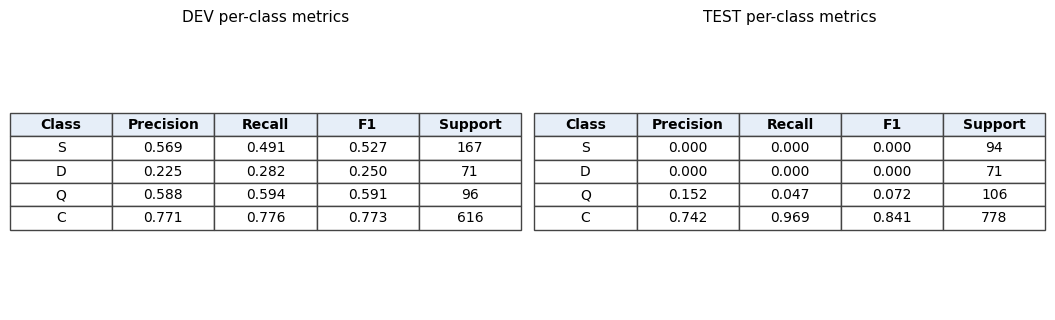

In [ ]:
# ============================================================
# DEV & TEST metrics tables (side-by-side)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

os.makedirs(out_dir_4, exist_ok=True)

HEADER_COLOR = "#E6EEF8"
EDGE_COLOR   = "#444444"

def build_prf_table(y_true, y_pred, id2label):
    label_ids = list(id2label.keys())
    target_names = [id2label[i] for i in label_ids]

    rep = classification_report(
        y_true, y_pred,
        labels=label_ids,
        target_names=target_names,
        output_dict=True,
        zero_division=0
    )

    rows = []
    for name in target_names:
        r = rep[name]
        rows.append([name, r["precision"], r["recall"], r["f1-score"], int(r["support"])])

    df = pd.DataFrame(rows, columns=["Class", "Precision", "Recall", "F1", "Support"])

    df_fmt = df.copy()
    for c in ["Precision", "Recall", "F1"]:
        df_fmt[c] = df_fmt[c].map(lambda x: f"{x:.3f}")
    df_fmt["Support"] = df_fmt["Support"].map(str)

    return df, df_fmt


def render_two_tables_side_by_side(dev_df_fmt, test_df_fmt, title=None, save_path=None):
    fig, axes = plt.subplots(
        1, 2,
        figsize=(12.5, 3.6),
        gridspec_kw={"wspace": 0.18}
    )

    for ax in axes:
        ax.axis("off")

    if title:
        fig.suptitle(title, y=0.98, fontsize=12)

    def add_table(ax, df_fmt, subtitle):
        ax.set_title(subtitle, pad=8, fontsize=11)

        tab = ax.table(
            cellText=df_fmt.values,
            colLabels=df_fmt.columns,
            cellLoc="center",
            loc="center"
        )

        tab.auto_set_font_size(False)
        tab.set_fontsize(10)
        tab.scale(1.15, 1.4)

        
        for (row, col), cell in tab.get_celld().items():
            cell.set_edgecolor(EDGE_COLOR)
            if row == 0:
                cell.set_facecolor(HEADER_COLOR)
                cell.set_text_props(weight="bold")

        return tab

    add_table(axes[0], dev_df_fmt, "DEV per-class metrics")
    add_table(axes[1], test_df_fmt, "TEST per-class metrics")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved image:", save_path)

    plt.show()


# dev
dev_pred = trainer_4.predict(dev_ds_4)
y_dev_true = dev_pred.label_ids
y_dev_pred = np.argmax(dev_pred.predictions, axis=-1)
dev_raw, dev_fmt = build_prf_table(y_dev_true, y_dev_pred, ID2LABEL_4)

# test
test_pred = trainer_4.predict(test_ds_4)
y_test_true = test_pred.label_ids
y_test_pred = np.argmax(test_pred.predictions, axis=-1)
test_raw, test_fmt = build_prf_table(y_test_true, y_test_pred, ID2LABEL_4)


img_path = os.path.join(out_dir_4, "dev_test_per_class_tables.png")
render_two_tables_side_by_side(
    dev_fmt,
    test_fmt,
    title="",
    save_path=img_path
)


## 2a(I)

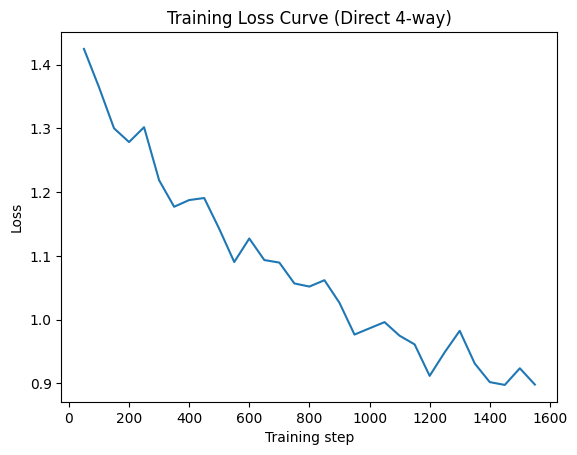

Saved: runs/direct_4way_bertweet_llrd/train_loss_curve.png
Saved: runs/direct_4way_bertweet_llrd/train_loss_curve.csv


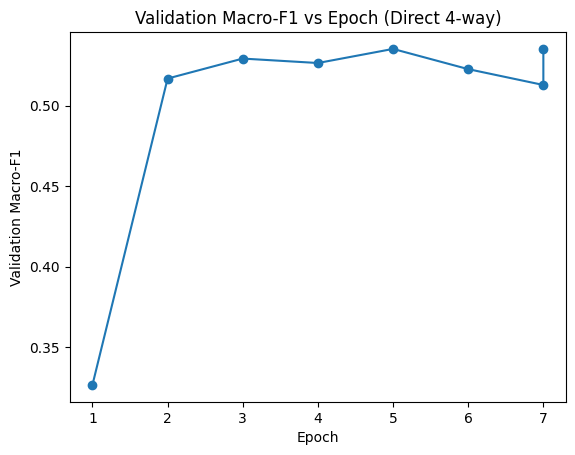

Saved: runs/direct_4way_bertweet_llrd/dev_macro_f1_vs_epoch.png
Saved: runs/direct_4way_bertweet_llrd/dev_macro_f1_vs_epoch.csv
Best dev macro-F1 row: {'epoch': 5.0, 'eval_macro_f1': 0.5353668870029165, 'eval_loss': 1.2303528785705566}


In [ ]:
# ============================================================
#   - Loss curve
#   - Validation macro-F1 vs epoch
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs(out_dir_4, exist_ok=True)

log_hist = getattr(trainer_4.state, "log_history", None)
if not log_hist:
    raise RuntimeError("trainer_4.state.log_history is empty. Ensure trainer_4.train() ran in the current session.")

logs = pd.DataFrame(log_hist)
loss_df = logs[["step", "epoch", "loss"]].dropna(subset=["loss"]).copy()
if len(loss_df) == 0:
    print("No training loss found in log_history (loss_df empty).")
else:
    plt.figure()
    plt.plot(loss_df["step"], loss_df["loss"])
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.title("Training Loss Curve (Direct 4-way)")
    loss_path = os.path.join(out_dir_4, "train_loss_curve.png")
    plt.savefig(loss_path, dpi=200, bbox_inches="tight")
    plt.show()

    loss_csv = os.path.join(out_dir_4, "train_loss_curve.csv")
    loss_df.to_csv(loss_csv, index=False)
    print("Saved:", loss_path)
    print("Saved:", loss_csv)

eval_cols = [c for c in logs.columns if c.startswith("eval_")]
if "eval_macro_f1" not in logs.columns:
    print("No eval_macro_f1 found in log_history. Available eval cols:", eval_cols)
else:
    f1_df = logs[["step", "epoch", "eval_macro_f1"]].dropna(subset=["eval_macro_f1"]).copy()
    if len(f1_df) == 0:
        print("No eval_macro_f1 rows found (f1_df empty).")
    else:
        f1_df["epoch"] = pd.to_numeric(f1_df["epoch"], errors="coerce")
        f1_df = f1_df.dropna(subset=["epoch"]).sort_values("epoch")

        plt.figure()
        plt.plot(f1_df["epoch"], f1_df["eval_macro_f1"], marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("Validation Macro-F1")
        plt.title("Validation Macro-F1 vs Epoch (Direct 4-way)")
        f1_path = os.path.join(out_dir_4, "dev_macro_f1_vs_epoch.png")
        plt.savefig(f1_path, dpi=200, bbox_inches="tight")
        plt.show()

        f1_csv = os.path.join(out_dir_4, "dev_macro_f1_vs_epoch.csv")
        f1_df.to_csv(f1_csv, index=False)
        print("Saved:", f1_path)
        print("Saved:", f1_csv)

if "eval_macro_f1" in logs.columns:
    f1_df2 = logs[["epoch", "eval_macro_f1", "eval_loss"]].dropna(subset=["eval_macro_f1"]).copy()
    if len(f1_df2) > 0:
        best_row = f1_df2.loc[f1_df2["eval_macro_f1"].idxmax()].to_dict()
        print("Best dev macro-F1 row:", best_row)


## 2a(II)

In [ ]:
import numpy as np
import pandas as pd


pred_test = trainer_4.predict(test_ds_4)
y_true = pred_test.label_ids
y_pred = np.argmax(pred_test.predictions, axis=-1)

labels = list(range(len(ID2LABEL_4)))
label_names = [ID2LABEL_4[i] for i in labels]


true_counts = pd.Series(y_true).value_counts().reindex(labels, fill_value=0)
pred_counts = pd.Series(y_pred).value_counts().reindex(labels, fill_value=0)

dist = pd.DataFrame({
    "label_id": labels,
    "label": label_names,
    "true_count": true_counts.values,
    "true_pct": (true_counts / max(1, true_counts.sum()) * 100).values,
    "pred_count": pred_counts.values,
    "pred_pct": (pred_counts / max(1, pred_counts.sum()) * 100).values,
})

print("\n=== TEST label distribution (true vs predicted) ===")
display(dist)


from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"true_{n}" for n in label_names], columns=[f"pred_{n}" for n in label_names])

row_sums = cm.sum(axis=1, keepdims=True)
cm_row_pct = np.divide(cm, np.maximum(row_sums, 1), dtype=float) * 100.0
cm_row_pct_df = pd.DataFrame(cm_row_pct, index=cm_df.index, columns=cm_df.columns)

print("\n=== Confusion matrix (counts) ===")
display(cm_df)

print("\n=== Confusion matrix (row-normalised % of true class) ===")
display(cm_row_pct_df.round(2))

pairs = []
for i in labels:
    for j in labels:
        if i == j:
            continue
        pairs.append({
            "true": ID2LABEL_4[i],
            "pred": ID2LABEL_4[j],
            "count": int(cm[i, j]),
            "pct_of_true_class": float(cm_row_pct[i, j]),
        })
pairs_df = pd.DataFrame(pairs).sort_values(["count", "pct_of_true_class"], ascending=False)

print("\n=== Top confusions (TEST) ===")
display(pairs_df.head(10))

from scipy.special import softmax

probs = softmax(pred_test.predictions, axis=-1)
conf = probs[np.arange(len(y_pred)), y_pred]

err_mask = (y_true != y_pred)
err_idx = np.where(err_mask)[0]

err_rows = []
for idx in err_idx:
    err_rows.append({
        "idx": int(idx),
        "tweet_id": test_df.iloc[idx].get("tweet_id", None),
        "true": ID2LABEL_4[int(y_true[idx])],
        "pred": ID2LABEL_4[int(y_pred[idx])],
        "pred_conf": float(conf[idx]),
        "source_text": test_df.iloc[idx].get("source_text", test_df.iloc[idx].get("source_norm", "")),
        "reply_text":  test_df.iloc[idx].get("reply_text",  test_df.iloc[idx].get("reply_norm", "")),
    })

err_df = pd.DataFrame(err_rows).sort_values("pred_conf", ascending=False)


minority_err = err_df[err_df["true"].isin(["S", "D", "Q"])].copy()
print("\n=== High-confidence errors where TRUE is minority class (S/D/Q) ===")
display(minority_err.head(12))


to_c = err_df[(err_df["true"].isin(["S","D","Q"])) & (err_df["pred"] == "C")].copy()
print("\n=== Errors: TRUE in {S,D,Q} but PRED = C ===")
display(to_c.head(12))


os.makedirs(out_dir_4, exist_ok=True)
dist.to_csv(os.path.join(out_dir_4, "test_true_vs_pred_distribution.csv"), index=False)
cm_df.to_csv(os.path.join(out_dir_4, "test_confusion_counts.csv"))
cm_row_pct_df.to_csv(os.path.join(out_dir_4, "test_confusion_row_pct.csv"))
pairs_df.to_csv(os.path.join(out_dir_4, "test_top_confusions.csv"), index=False)
err_df.to_csv(os.path.join(out_dir_4, "test_error_examples_all.csv"), index=False)
minority_err.to_csv(os.path.join(out_dir_4, "test_error_examples_minority.csv"), index=False)

print("\nSaved CSVs into:", out_dir_4)



=== TEST label distribution (true vs predicted) ===


,label_id,label,true_count,true_pct,pred_count,pred_pct
0,0,S,94,8.960915,0,0.000000
1,1,D,71,6.768351,0,0.000000
2,2,Q,106,10.104862,33,3.145853
3,3,C,778,74.165872,1016,96.854147



=== Confusion matrix (counts) ===


,pred_S,pred_D,pred_Q,pred_C
true_S,0,0,2,92
true_D,0,0,2,69
true_Q,0,0,5,101
true_C,0,0,24,754



=== Confusion matrix (row-normalised % of true class) ===


...


=== High-confidence errors where TRUE is minority class (S/D/Q) ===


,idx,tweet_id,true,pred,pred_conf,source_text,reply_text
44,184,758408204195880960,D,C,0.616241,nan,nan
199,760,544294893146091520,S,C,0.616241,nan,nan
228,856,771146763168210944,S,C,0.616241,nan,nan
70,280,767732633337864193,Q,C,0.616241,nan,nan
28,120,544283072720805890,Q,C,0.616241,nan,nan
216,824,767734806402609152,Q,C,0.616241,nan,nan
127,504,764958204493176832,D,C,0.616241,nan,nan
277,1016,758396240619048960,Q,C,0.616241,nan,nan
207,792,498490564887990272,Q,C,0.616241,nan,nan
42,178,524924798993199105,Q,C,0.581325,nan,nan



=== Errors: TRUE in {S,D,Q} but PRED = C ===


,idx,tweet_id,true,pred,pred_conf,source_text,reply_text
44,184,758408204195880960,D,C,0.616241,nan,nan
199,760,544294893146091520,S,C,0.616241,nan,nan
228,856,771146763168210944,S,C,0.616241,nan,nan
70,280,767732633337864193,Q,C,0.616241,nan,nan
28,120,544283072720805890,Q,C,0.616241,nan,nan
216,824,767734806402609152,Q,C,0.616241,nan,nan
127,504,764958204493176832,D,C,0.616241,nan,nan
277,1016,758396240619048960,Q,C,0.616241,nan,nan
207,792,498490564887990272,Q,C,0.616241,nan,nan
42,178,524924798993199105,Q,C,0.581325,nan,nan



Saved CSVs into: runs/direct_4way_bertweet_llrd


In [ ]:
import os, json, platform
import numpy as np
import pandas as pd

import torch
import transformers
import datasets
import sklearn

os.makedirs(out_dir_4, exist_ok=True)

def label_dist_table(df: pd.DataFrame, label_col: str) -> pd.DataFrame:
    vc = df[label_col].value_counts(dropna=False)
    out = pd.DataFrame({
        "label": vc.index.astype(str),
        "count": vc.values,
        "pct": (vc.values / max(1, vc.values.sum()) * 100.0)
    })
    return out.sort_values("count", ascending=False).reset_index(drop=True)

train_dist = label_dist_table(train_df, LABEL_COL)
dev_dist   = label_dist_table(dev_df, LABEL_COL)
test_dist  = label_dist_table(test_df, LABEL_COL) if LABEL_COL in test_df.columns else None

print("TRAIN label distribution:")
display(train_dist)
print("DEV label distribution:")
display(dev_dist)
if test_dist is not None:
    print("TEST label distribution:")
    display(test_dist)

train_dist.to_csv(os.path.join(out_dir_4, "train_label_distribution.csv"), index=False)
dev_dist.to_csv(os.path.join(out_dir_4, "dev_label_distribution.csv"), index=False)
if test_dist is not None:
    test_dist.to_csv(os.path.join(out_dir_4, "test_label_distribution.csv"), index=False)

run_config = {
    "model_name": MODEL_NAME if "MODEL_NAME" in globals() else None,
    "max_len": MAX_LEN if "MAX_LEN" in globals() else None,
    "learning_rate": LR if "LR" in globals() else None,
    "weight_decay": WEIGHT_DECAY if "WEIGHT_DECAY" in globals() else None,
    "warmup_ratio": WARMUP_RATIO if "WARMUP_RATIO" in globals() else None,
    "batch_size_train": BS_TRAIN if "BS_TRAIN" in globals() else None,
    "batch_size_eval": BS_EVAL if "BS_EVAL" in globals() else None,
    "grad_accum": GRAD_ACCUM if "GRAD_ACCUM" in globals() else None,
    "num_epochs": EPOCHS_4 if "EPOCHS_4" in globals() else None,
    "max_grad_norm": MAX_GRAD_NORM if "MAX_GRAD_NORM" in globals() else None,
    "label_smoothing": LABEL_SMOOTHING if "LABEL_SMOOTHING" in globals() else None,
    "layer_decay": LAYER_DECAY if "LAYER_DECAY" in globals() else None,
    "dropout": DROPOUT if "DROPOUT" in globals() else None,
    "imbalance_mitigation": "weighted_cross_entropy (sqrt inverse freq)",
    "class_weights": w4.detach().cpu().numpy().tolist() if "w4" in globals() else None,
    "seed": SEED if "SEED" in globals() else None,
    "eval_strategy": "epoch",
    "metric_for_best_model": "macro_f1",
    "load_best_model_at_end": True,
}

versions = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "datasets": datasets.__version__,
    "sklearn": sklearn.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
}

with open(os.path.join(out_dir_4, "run_config_4way.json"), "w") as f:
    json.dump(run_config, f, indent=2)

with open(os.path.join(out_dir_4, "versions.json"), "w") as f:
    json.dump(versions, f, indent=2)

print("Saved:", os.path.join(out_dir_4, "run_config_4way.json"))
print("Saved:", os.path.join(out_dir_4, "versions.json"))


TRAIN label distribution:


,label,count,pct
0,C,2291,64.191650
1,S,743,20.818156
2,D,273,7.649201
3,Q,262,7.340992


DEV label distribution:


,label,count,pct
0,C,616,64.842105
1,S,167,17.578947
2,Q,96,10.105263
3,D,71,7.473684


TEST label distribution:


,label,count,pct
0,C,778,74.165872
1,Q,106,10.104862
2,S,94,8.960915
3,D,71,6.768351


Saved: runs/direct_4way_bertweet_llrd/run_config_4way.json
Saved: runs/direct_4way_bertweet_llrd/versions.json


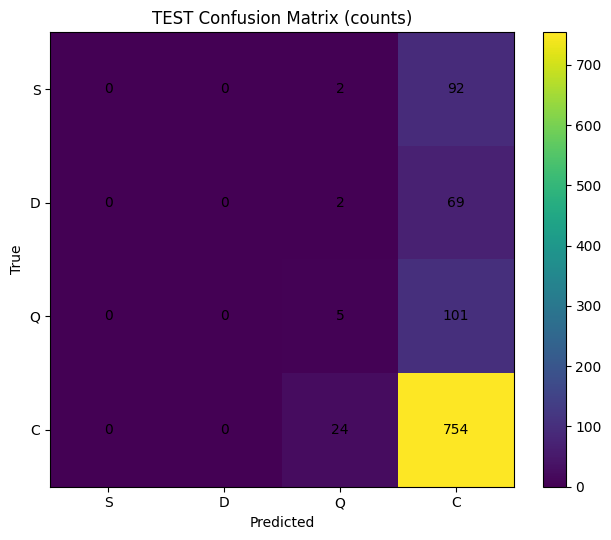

Saved: runs/direct_4way_bertweet_llrd/test_confusion_counts.png


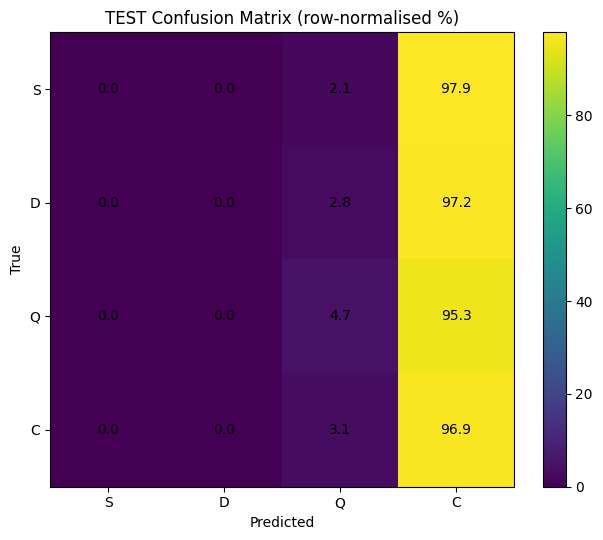

Saved: runs/direct_4way_bertweet_llrd/test_confusion_rowpct.png


In [ ]:

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

os.makedirs(out_dir_4, exist_ok=True)

if "y_true" not in globals() or "y_pred" not in globals():
    pred_test = trainer_4.predict(test_ds_4)
    y_true = pred_test.label_ids
    y_pred = np.argmax(pred_test.predictions, axis=-1)

labels = list(range(len(ID2LABEL_4)))
label_names = [ID2LABEL_4[i] for i in labels]

cm = confusion_matrix(y_true, y_pred, labels=labels)

def plot_cm(mat, title, out_path, fmt=None):
    plt.figure(figsize=(6.5, 5.5))
    plt.imshow(mat, aspect="auto")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(label_names)), label_names)
    plt.yticks(range(len(label_names)), label_names)


    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            s = f"{val:.1f}" if isinstance(val, float) and fmt == "float" else f"{int(val)}"
            plt.text(j, i, s, ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

plot_cm(cm, "TEST Confusion Matrix (counts)", os.path.join(out_dir_4, "test_confusion_counts.png"))

row_sums = cm.sum(axis=1, keepdims=True)
cm_rowpct = np.divide(cm, np.maximum(row_sums, 1)) * 100.0
plot_cm(cm_rowpct, "TEST Confusion Matrix (row-normalised %)", os.path.join(out_dir_4, "test_confusion_rowpct.png"), fmt="float")


In [ ]:

import numpy as np
from sklearn.metrics import f1_score, accuracy_score

majority_label = train_df[LABEL_COL].value_counts().idxmax()
maj_id = LABEL2ID_4[str(majority_label)]


dev_true = dev_df[LABEL_COL].astype(str).map(LABEL2ID_4).values
dev_pred = np.full_like(dev_true, fill_value=maj_id)

print("Majority label (from TRAIN):", majority_label)
print("DEV baseline accuracy:", accuracy_score(dev_true, dev_pred))
print("DEV baseline macro-F1:", f1_score(dev_true, dev_pred, average="macro"))

if LABEL_COL in test_df.columns:
    test_true = test_df[LABEL_COL].astype(str).map(LABEL2ID_4).values
    test_pred = np.full_like(test_true, fill_value=maj_id)
    print("TEST baseline accuracy:", accuracy_score(test_true, test_pred))
    print("TEST baseline macro-F1:", f1_score(test_true, test_pred, average="macro"))


Majority label (from TRAIN): C
DEV baseline accuracy: 0.6484210526315789
DEV baseline macro-F1: 0.1966794380587484
TEST baseline accuracy: 0.7416587225929456
TEST baseline macro-F1: 0.21291735084838534


#### Results:

===== DEV (DIRECT 4-WAY) =====
Accuracy: 0.6705263157894736
Macro-F1: 0.5353668870029165

===== TEST (DIRECT 4-WAY) =====
Accuracy: 0.7235462345090562
Macro-F1: 0.22813053904702324